In [ ]:
#load all python and visualization packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests
from PIL import Image
import requests
from io import BytesIO
import plotly.graph_objects as go
from wordcloud import WordCloud
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted

In [ ]:
pets = pd.read_csv('dogscats.csv') #load .csv file with data as a dataframe

print(pets)

           _id  Year  FSA ANIMAL_TYPE  PRIMARY_BREED
0            1  2023  M1C         DOG    GOLDEN RETR
1            2  2023  M3A         DOG  CAVALIER SPAN
2            3  2023  M4T         DOG  SC WHEAT TERR
3            4  2023  M8X         CAT    DOMESTIC SH
4            5  2023  M3C         CAT    DOMESTIC SH
...        ...   ...  ...         ...            ...
198603  198604  2026  M2N         DOG    GOLDEN RETR
198604  198605  2026  M3J         DOG   AMER BULLDOG
198605  198606  2025  M3C         CAT    DOMESTIC SH
198606  198607  2025  NaN         DOG    COCKER SPAN
198607  198608  2026  M4K         DOG  BORDER COLLIE

[198608 rows x 5 columns]


In [ ]:
#counting total registrations of dogs and cats per year
counts = (
        pets.groupby(['Year','ANIMAL_TYPE'])    #selecting by year and animal type
        .size()                                 #counting number of rows for total unqiue registrations
        .unstack(fill_value=0)                  #separate columns for dogs and cats
        .sort_index()                           #sort the years
)

print(counts)

ANIMAL_TYPE    CAT    DOG
Year                     
2023         17534  44423
2024         17926  44302
2025         20472  47233
2026          2168   4550


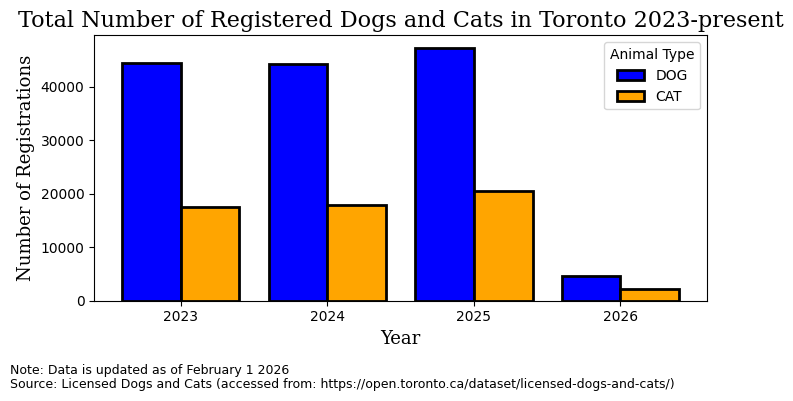

In [38]:
years = counts.index.to_numpy()           #make array of the years 
x = np.arange(len(years))                 #makes array of year to numberic positions for the plot

dogs = counts["DOG"].to_numpy()           #dog registrations per year
cats = counts["CAT"].to_numpy()           #cat registrations per year

bar_width = 0.4                           #bar width

fig, ax = plt.subplots(figsize=(8,4))     #create the grouped bar chart

ax.bar(x - bar_width/2, dogs,             #plot dogs slightly left of the center of each year 
       width = bar_width,
       color = 'blue',
       edgecolor='black',
       linewidth=2,
       label = "DOG")

ax.bar(x + bar_width/2, cats,             #plot cats slightly right of the center of each year
       width = bar_width,
       color = 'orange',
       edgecolor='black',
       linewidth=2,
       label = "CAT")

ax.set_xticks(x)

ax.set_xticklabels(years)                 #relabel the numeric ticks with the actual year labels

#set chart title, axis labels, and legend title
ax.set_title("Total Number of Registered Dogs and Cats in Toronto 2023-present", fontfamily='serif', fontsize=16)
ax.set_xlabel ("Year", fontfamily='serif', fontsize=13)
ax.set_ylabel("Number of Registrations", fontfamily='serif', fontsize=13)
ax.legend(title="Animal Type")


plt.tight_layout(rect=[0, 0.08, 0.90, 1])  #adjusting layout and ensuring white space for source information

fig.text(                                  
    0.01, 0.045,
    "Note: Data is updated as of February 1 2026",
    ha="left",
    va="bottom",
    fontsize=9,
    color="black"
)

fig.text(                                  #adding text to show source information
    0.01, 0.01,
    "Source: Licensed Dogs and Cats (accessed from: https://open.toronto.ca/dataset/licensed-dogs-and-cats/)",
    ha="left",
    va="bottom",
    fontsize=9,
    color="black"
)


plt.show()
